In [1]:
import numpy as np
import time
from scipy.optimize import least_squares, newton
import matplotlib.pyplot as plt
%matplotlib inline

First, we need to figure out how we can approximate derivatives for functions. We can use finite differences for this

In [2]:
def fwd_finite_diff(F, x, Fx):
    x = np.asarray(x).ravel().astype(float)
    fbase = np.asarray(Fx).ravel().astype(float)
    # if fbase is scalar-like, make it 1D array
    # in numpy ravel already does that
    n = x.size
    # Number of outputs: if fbase is scalar, length is 1
    n_outs = fbase.size

    # ---------- HERE IS THE STEP SIZE ----------
    h = 1e-12
    # -------------------------------------------

    if n_outs > 1:
        J = np.zeros((n_outs, n), dtype=float)
        for i in range(n):
            xperturb = x.copy()
            xperturb[i] += h
            J[:, i] = (np.asarray(F(xperturb)).ravel() - fbase) / h
    else:
        # For scalar outputs, return gradient (n x 1) shaped as (n,) for convenience
        J = np.zeros((n,), dtype=float)
        for i in range(n):
            xperturb = x.copy()
            xperturb[i] += h
            J[i] = (float(F(xperturb)) - float(fbase)) / h
    return J



First, we can look at using gradient descent. This is mathemtically less robust than Newton based methods, but can outperform when we start far from the minimum or we cannot calculate second derivatives

In [3]:

def Gradient_descent(f, gradf, x0):
    """
    GRAD_DESCENT_LINESEARCH  Gradient descent with Armijo backtracking.
    (Translated from MATLAB; comments preserved)
    """
    # parse inputs & defaults
    tol_grad = 1e-6
    tol_step = 1e-12
    maxIter = int(1e4)
    alpha0 = 1.0
    rho = 0.5
    c = 1e-4
    verbose = False

    x = np.asarray(x0).ravel().astype(float)
    n = x.size

    # history
    info = {}
    info['iter'] = 0
    info['fvals'] = []
    info['gradnorm'] = []
    info['steps'] = []
    info['alphas'] = []
    info['xvals'] = []

    # initial eval
    fx = f(x)
    if gradf is not None:
        g = np.asarray(gradf(x)).ravel().astype(float)
    else:
        g = fwd_finite_diff(lambda y: f(y), x, fx)
    g = np.asarray(g).ravel()
    gnorm = np.linalg.norm(g)

    info['fvals'].append(fx)
    info['xvals'].append(x.copy())
    info['gradnorm'].append(gnorm)

    # main loop
    for k in range(1, maxIter + 1):
        if gnorm <= tol_grad:
            info['iter'] = k - 1
            if verbose:
                print('Converged: ||grad|| <= tol_grad')
            return x, info

        p = -g  # steepest descent direction

        # Armijo backtracking line search
        # This effectively determines how far down the gradient we should step
        alpha = alpha0
        phi0 = fx
        phi_grad_dir = float(np.dot(g, p))  # should be negative
        ls_iter = 0
        maxLS = 50
        while ls_iter < maxLS:
            x_new = x + alpha * p
            f_new = float(f(x_new))
            if f_new <= phi0 + c * alpha * phi_grad_dir:
                break
            else:
                alpha = rho * alpha
                ls_iter += 1

        if ls_iter >= maxLS:
            # failed to find sufficient decrease: stop or take tiny step
            alpha = 1e-8
            x_new = x + alpha * p
            f_new = float(f(x_new))
            if not isfinite(f_new):
                warnings.warn('Line search failed; stopping.')
                info['iter'] = k - 1
                return x, info

        step = alpha * p
        x = x_new
        fx = f_new

        # update gradient
        if gradf is not None:
            g = np.asarray(gradf(x)).ravel()
        else:
            g = fwd_finite_diff(lambda y: f(y), x, fx)
        g = np.asarray(g).ravel()
        gnorm = np.linalg.norm(g)

        # record
        info['fvals'].append(fx)
        info['xvals'].append(x.copy())
        info['gradnorm'].append(gnorm)
        info['steps'].append(np.linalg.norm(step))
        info['alphas'].append(alpha)
        info['iter'] = k

        if verbose and (k % 100 == 0):
            print('iter {:3d}: f = {:.6e}, ||g|| = {:.6e}, alpha={:.3e}, ||step||={:.3e}'.format(
                k, fx, gnorm, alpha, np.linalg.norm(step)
            ))

        if np.linalg.norm(step) <= tol_step:
            if verbose:
                print('Converged: step size below tol_step')
            return x, info

    if verbose:
        print('Reached maxIter = {}'.format(maxIter))
    return x, info

Now, we can define the Newton routine for either Vector valued or scalar valued functions

In [4]:

def Newton_Vector(F, J, x0, tol=None, maxIter=None):
    if tol is None or tol == []:
        tol = 1e-8
    if maxIter is None or maxIter == []:
        maxIter = 50 # Max iterations control when we stop applying gradient descent

    x = np.asarray(x0).ravel().astype(float)
    n = x.size
    info = {}
    info['iter'] = 0
    info['residual'] = []
    info['dxnorm'] = []
    info['converged'] = False

    for k in range(1, int(maxIter) + 1):
        Fx = F(x)
        # ensure vector form
        Fx = np.asarray(Fx).ravel().astype(float)
        r = np.linalg.norm(Fx)
        info['residual'].append(r)

        if r <= tol:
            info['converged'] = True
            info['iter'] = k - 1
            return x, info

        # If an analytic Jacobian J was provided (not None), use it; else use FD
        if J is not None:
            Jx = np.asarray(J(x), dtype=float)
        else:
            Jx = fwd_finite_diff(F, x, Fx)

        # Solve J * dx = -F
        try:
            # Prefer a direct solve when Jx is square
            if Jx.shape[0] == Jx.shape[1]:
                dx = -np.linalg.solve(Jx, Fx)
            else:
                # non-square (over/underdetermined) - use least squares solve
                # solve Jx * dx = -Fx in least-squares sense
                dx, *_ = np.linalg.lstsq(Jx, -Fx, rcond=None)
        except Exception:
            # fallback to pseudoinverse
            dx = -np.dot(np.linalg.pinv(Jx), Fx)

        dx = np.asarray(dx).ravel()
        info['dxnorm'].append(np.linalg.norm(dx))

        # Simple damping if step is huge (optional heuristic) - commented out as in your MATLAB
        # if np.linalg.norm(dx) > 1:
        #     t = 1.0
        #     while t > 1e-6:
        #         xnew = x + t * dx
        #         if np.linalg.norm(F(xnew)) < r:
        #             x = xnew
        #             break
        #         t = t / 2.0
        #     if t <= 1e-6:
        #         x = x + dx
        # else:
        x = x + dx

        info['iter'] = k

    # final residual
    info['converged'] = (np.linalg.norm(F(x)) <= tol)
    return x, info


def Newton_scalar(f, df, x0, tol=None, maxIter=None):
    if tol is None or tol == []:
        tol = 1e-10
    if maxIter is None or maxIter == []:
        maxIter = 50

    # Accept scalar or 1-element array
    x = np.asarray(x0).ravel()
    if x.size != 1:
        # If user passed vector, try to treat as scalar if length==1, else error
        if x.size == 1:
            x = float(x[0])
        else:
            raise ValueError("newton_scalar expects a scalar initial guess x0.")
    x = float(x)

    info = {}
    info['iter'] = 0
    info['fvals'] = []
    info['dx'] = []
    info['converged'] = False

    for k in range(1, int(maxIter) + 1):
        fx = float(f(x))
        info['fvals'].append(fx)
        if abs(fx) <= tol:
            info['converged'] = True
            info['iter'] = k - 1
            return x, info

        if df is not None:
            dfx = float(df(x))
        else:
            # Finite difference derivative (forward) consistent with original code
            dfx = fwd_finite_diff(f, x, fx)

        if dfx == 0:
            # derivative zero — fallback: small perturbation
            print(f'Derivative zero at x = {x}. Stopping.')
            info['iter'] = k - 1
            return x, info

        dx = -fx / dfx

        # Simple damping/line search to ensure reduction in |f| (commented in your code)
        # t = 1
        # while t > 1e-8:
        #     xnew = x + t*dx
        #     if abs(f(xnew)) < abs(fx):
        #         x = xnew
        #         break
        #     t = t/2
        # if t <= 1e-8:
        #     x = x + dx

        # Following your provided code's active behavior: accept full step
        x = x + dx

        info['dx'].append(dx)
        info['iter'] = k

    info['converged'] = (abs(f(x)) <= tol)
    return x, info

# Newton function that calls all the above
def Newton_numpy(f, df, x0, tol, maxIter, problem_type):
    """
    Wrapper function that routes to scalar or vector Newton.
    """
    if problem_type.lower() == 'scalar':
        x, info = Newton_scalar(f, df, x0, tol, maxIter)
    elif problem_type.lower() == 'vector':
        x, info = Newton_Vector(f, df, x0, tol, maxIter)
    else:
        raise ValueError('Incorrect type variable: specify as "vector" or "scalar"')
    return x, info



Now we start with a somewhat basic vector valued root finding problem (i.e., finding where both entries are zero)

In [5]:
# Define F exactly as in MATLAB (expects x as 1-D numpy array of length 2)
def F_vec(x):
    # ensure x is array-like
    x = np.asarray(x).ravel()
    return np.array([
        x[0] ** 2 + x[0] * x[1] ** 3 - 9,
        3 * x[0] ** 2 * x[1] - x[1] ** 3 - 4
    ], dtype=float)

Now run the optimization. You can uncomment the Jacobian to provide its analytical form as well.

In [6]:
tol = 1e-12
maxIter = int(1e3)
problem_type = 'vector'
##########################################################################################
## HERE IS THE INITIAL CONDITIONS
# Consider initial conditions on the domain [-5,5]
x0 = np.array([0.01, 0.01], dtype=float)  # Change this to test different initial conditions
###########################################################################################

df1 = None  # pass None to indicate "empty" / use finite differences
# OR provide the Jacobian:
# def df1(x):
#     x = np.asarray(x).ravel()
#     return np.array([
#         [2*x[0] + x[1]**3, 3*x[0]*x[1]**2],
#         [6*x[0]*x[1],       3*x[0]**2 - 3*x[1]**2]
#     ], dtype=float)

t0 = time.time()
x, info = Newton_numpy(F_vec, df1, x0, tol, maxIter, problem_type)
t_elapsed = time.time() - t0

print(f"Elapsed time: {t_elapsed:.6f} s")
# Note: info['residual'] might be empty if immediate convergence; guard access
final_residual = info['residual'][-1] if len(info['residual']) > 0 else np.nan
print("Results: number evals {}, minimum {}, solution x={:.6f} {:.6f}".format(
    info['iter'], final_residual, x[0], x[1]
))

Elapsed time: 0.159856 s
Results: number evals 14, minimum 1.9860273225978185e-15, solution x=2.998365 0.148431


We can plot the results here as well.

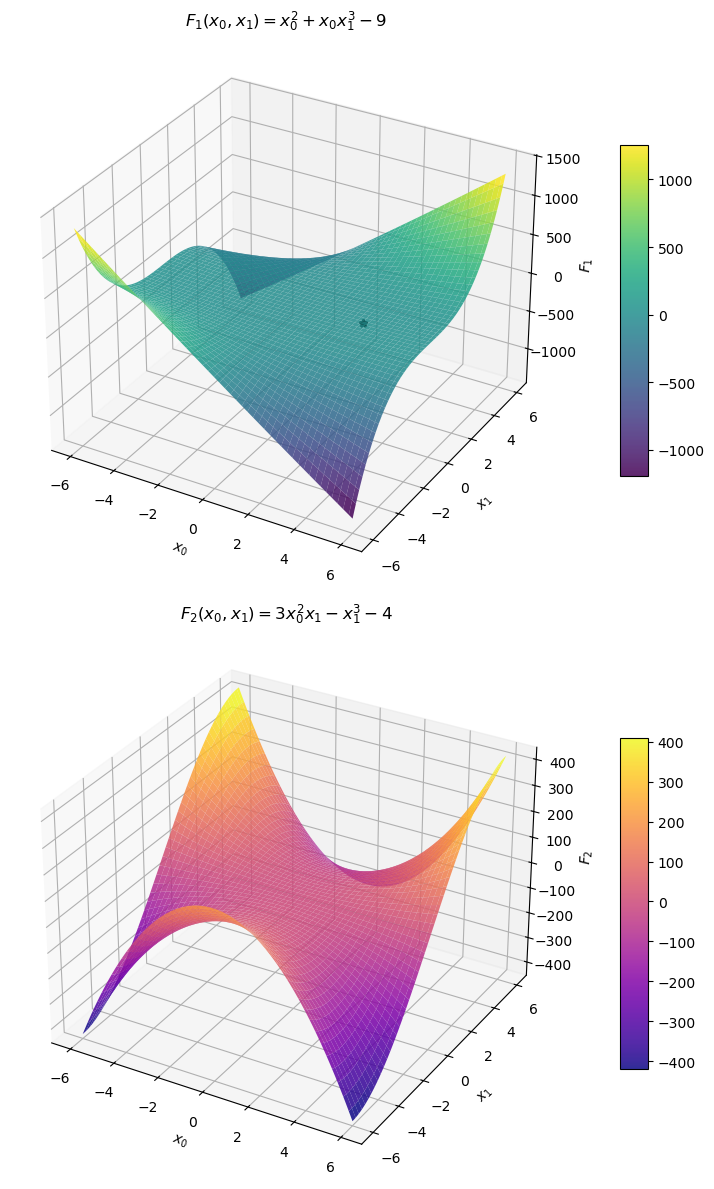

In [7]:
# Create a grid of x0 and x1 values
x0_vals = np.linspace(-6, 6, 150)
x1_vals = np.linspace(-6, 6, 150)

X0, X1 = np.meshgrid(x0_vals, x1_vals)

# Evaluate each component of F_vec on the grid
Z1 = X0**2 + X0 * X1**3 - 9
Z2 = 3 * X0**2 * X1 - X1**3 - 4
Z1_opt = x[0]**2 + x[0] * x[1]**3 - 9
Z2_opt = 3 * x[0]**2 * x[1] - x[1]**3 - 4

# Create figure
fig = plt.figure(figsize=(12, 12))

# Plot first component
ax1 = fig.add_subplot(2, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X0, X1, Z1, cmap="viridis", alpha=0.85)
ax1.scatter(x[0],x[1],Z1_opt,c='black',marker='*',linewidth=2)
ax1.set_title(r"$F_1(x_0, x_1) = x_0^2 + x_0x_1^3 - 9$")
ax1.set_xlabel(r"$x_0$")
ax1.set_ylabel(r"$x_1$")
ax1.set_zlabel(r"$F_1$")

fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=12)

# Plot second component
ax2 = fig.add_subplot(2, 1, 2, projection="3d")
surf2 = ax2.plot_surface(X0, X1, Z2, cmap="plasma", alpha=0.85)
ax1.scatter(x[0],x[1],Z2_opt,c='black',marker='*',linewidth=2)

ax2.set_title(r"$F_2(x_0, x_1) = 3x_0^2x_1 - x_1^3 - 4$")
ax2.set_xlabel(r"$x_0$")
ax2.set_ylabel(r"$x_1$")
ax2.set_zlabel(r"$F_2$")

fig.colorbar(surf2, ax=ax2, shrink=0.6, aspect=12)

plt.tight_layout()
plt.show()

Finally, let's consider a vector input, but scalar output, function. This is given by \
$\phi(x)=\frac{1}{2} ([1.5-x_0 (1-x_1 )]^2+[2.25-x_0 (1-x_0^2 )]^2 )$.

In [8]:
def phi(x):
    # function phi = HW3_phi(x)
    # term1 = 1.5 - x(1)*(1-x(2));
    # term2 = 2.25 - x(1)*(1-x(2)^2);
    # phi = 0.5*(term1.^2+term2.^2);
    x = np.asarray(x).ravel()
    term1 = 1.5 - x[0] * (1 - x[1])
    term2 = 2.25 - x[0] * (1 - x[1] ** 2)
    phi = 0.5 * (term1 ** 2 + term2 ** 2)
    return float(phi)

Now we can try to find the minimum of this function. Since it is a sum of squares, it will be positive, hence the smallest minimum is 0

C:\Users\mjcol\AppData\Local\Temp\ipykernel_40448\2048659855.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J[i] = (float(F(xperturb)) - float(fbase)) / h


Elapsed time 0.071464 s
Results: number evals 1518, minimum 1.3260696589317539e-11, solution x=2.999971 0.499994


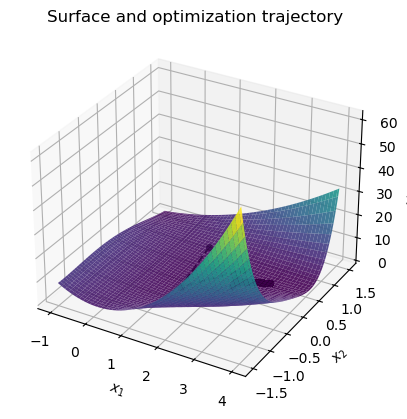

In [9]:

# First, let's visualize this function
x1_space = np.linspace(-1, 4, 100)
x2_space = np.linspace(-1.5, 1.5, 100)
xmesh1, xmesh2 = np.meshgrid(x1_space, x2_space)
phi_eval = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        phi_eval[i, j] = phi(np.array([xmesh1[i, j], xmesh2[i, j]]))

# Figure on the whole domain (3D surface)
fig = plt.figure(1)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xmesh1, xmesh2, phi_eval, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$\phi(x_1,x_2)$')

# First, we will solve the problem using gradient descent.
x0 = np.array([1.0, 0.8])  # CHANGE THIS FOR THE INITIAL GUESS
grad_phi = None

# Apply gradient descent; use this for part (iii)
t0 = time.time()
x, info = Gradient_descent(phi, grad_phi, x0)
t_elapsed = time.time() - t0

# Uncomment for part (iv) to use Newton method
# Hessf = None
# x, info = Newton_minimize(phi, grad_phi, Hessf, x0)

print('Elapsed time {:.6f} s'.format(t_elapsed))
print('Results: number evals {}, minimum {}, solution x={:.6f} {:.6f}'.format(
    info['iter'], info['fvals'][-1], x[0], x[1]
))

phi_traj = np.zeros(len(info['fvals']))
xvals = np.asarray(info['xvals'])
for i in range(len(info['fvals'])):
    phi_traj[i] = phi(xvals[i, :])

# Plot the trajectory on the surface
ax.plot(xvals[:, 0], xvals[:, 1], phi_traj, '--o', color='k', markersize=4)
plt.title('Surface and optimization trajectory')
plt.show()